In [1]:
!pip install lasio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lasio


In [3]:
from google.colab import files
uploaded = files.upload()

Saving ichthys_deep_1_welldata.las to ichthys_deep_1_welldata.las


In [4]:
las=lasio.read("ichthys_deep_1_welldata.las",  engine='normal', use_normal_engine_for_wrapped=True)

df=las.df()
print(df.head())
print(las.keys())

          AFEC  ANEC  APLC  BS  CALI  DENS  DENSC  DRH  DT  DTCO  ...  PR  \
DEPTH                                                             ...       
233.1720   NaN   NaN   NaN NaN   NaN   NaN    NaN  NaN NaN   NaN  ... NaN   
233.3244   NaN   NaN   NaN NaN   NaN   NaN    NaN  NaN NaN   NaN  ... NaN   
233.4768   NaN   NaN   NaN NaN   NaN   NaN    NaN  NaN NaN   NaN  ... NaN   
233.6292   NaN   NaN   NaN NaN   NaN   NaN    NaN  NaN NaN   NaN  ... NaN   
233.7816   NaN   NaN   NaN NaN   NaN   NaN    NaN  NaN NaN   NaN  ... NaN   

          PR_C  RESD  RESM  RESS  RHOM  SIGF  TENS  VPVS  VPVS_C  
DEPTH                                                             
233.1720   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN     NaN  
233.3244   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN     NaN  
233.4768   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN     NaN  
233.6292   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN     NaN  
233.7816   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN  

In [5]:
df02=las.df()

In [6]:
df02.reset_index(inplace=True)

In [7]:
df02.columns

Index(['DEPTH', 'AFEC', 'ANEC', 'APLC', 'BS', 'CALI', 'DENS', 'DENSC', 'DRH',
       'DT', 'DTCO', 'DTCO_C', 'DTSH', 'DTSM_C', 'FPLC', 'GR', 'HFK', 'HTHO',
       'HURA', 'NDS', 'NEUT', 'PEF', 'PR', 'PR_C', 'RESD', 'RESM', 'RESS',
       'RHOM', 'SIGF', 'TENS', 'VPVS', 'VPVS_C'],
      dtype='object')

In [8]:
df02=df02.rename( columns={
    'NEUT':'NPHI',
    'RHOM':'RHOB'
})

In [9]:
df02=df02.dropna(subset=[r'RHOB','NPHI','GR','CALI','DTCO','RESS','RESM','RESD','BS'])

In [10]:
top_depth=2972
bottom_depth=4869

In [11]:
df2=df02[(df02['DEPTH']>=top_depth) & (df02['DEPTH']<=bottom_depth)].copy()

df2=df2.reset_index(drop=True)

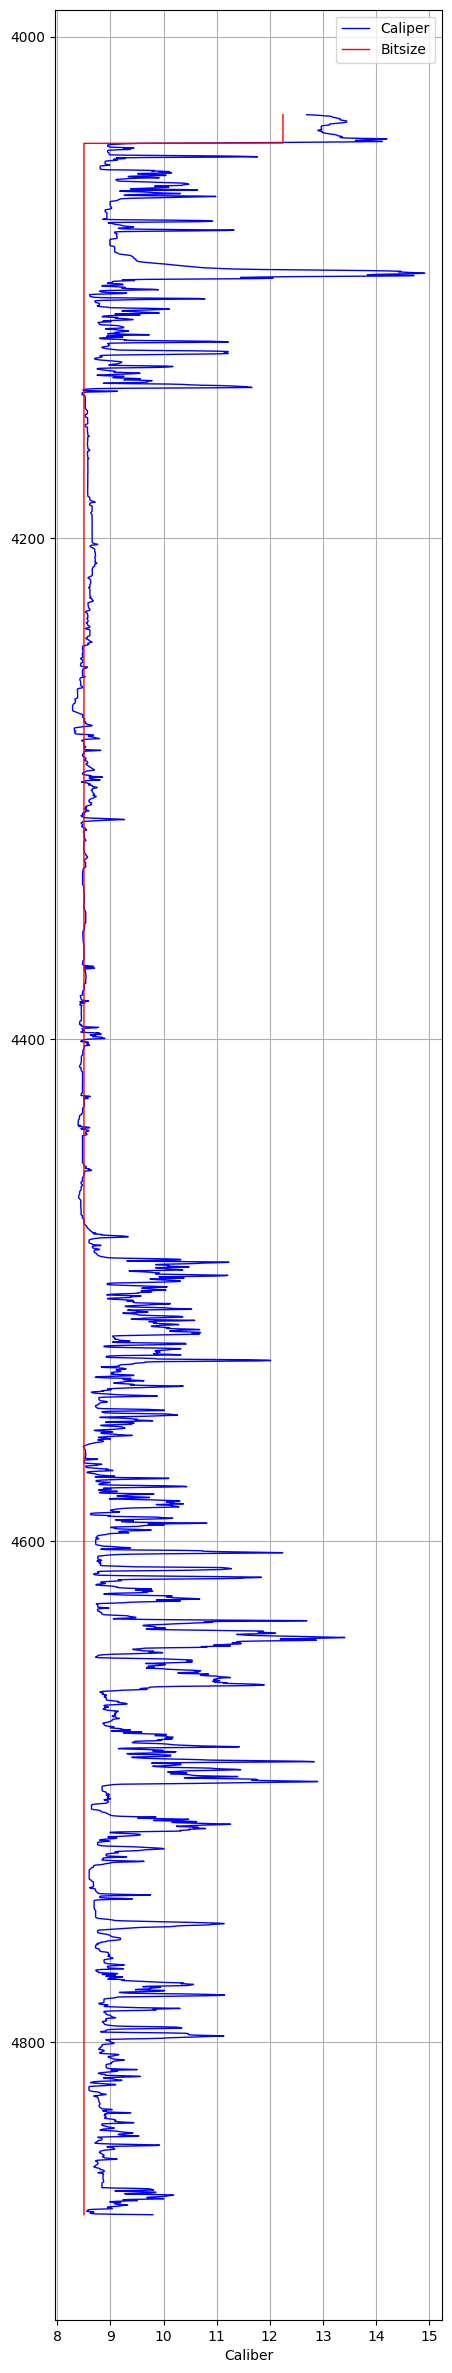

In [12]:
fig,ax= plt.subplots(figsize=(5,30))

ax.plot(df2['CALI'],df2['DEPTH'],color='blue',label='Caliper',lw=1)
ax.plot(df2['BS'],df2['DEPTH'],color='red',label='Bitsize',lw=1)
ax.set_xlabel('Caliber')
ax.grid()

ax.legend()
plt.gca().invert_yaxis()

In [13]:
df2['RHOB_smooth'] = df2['RHOB'].rolling(window=20, center=True).median()
df2['NPHI_smooth'] = df2['NPHI'].rolling(window=20, center=True).median()
df2['GR_smooth'] = df2['GR'].rolling(window=10, center=True).median()

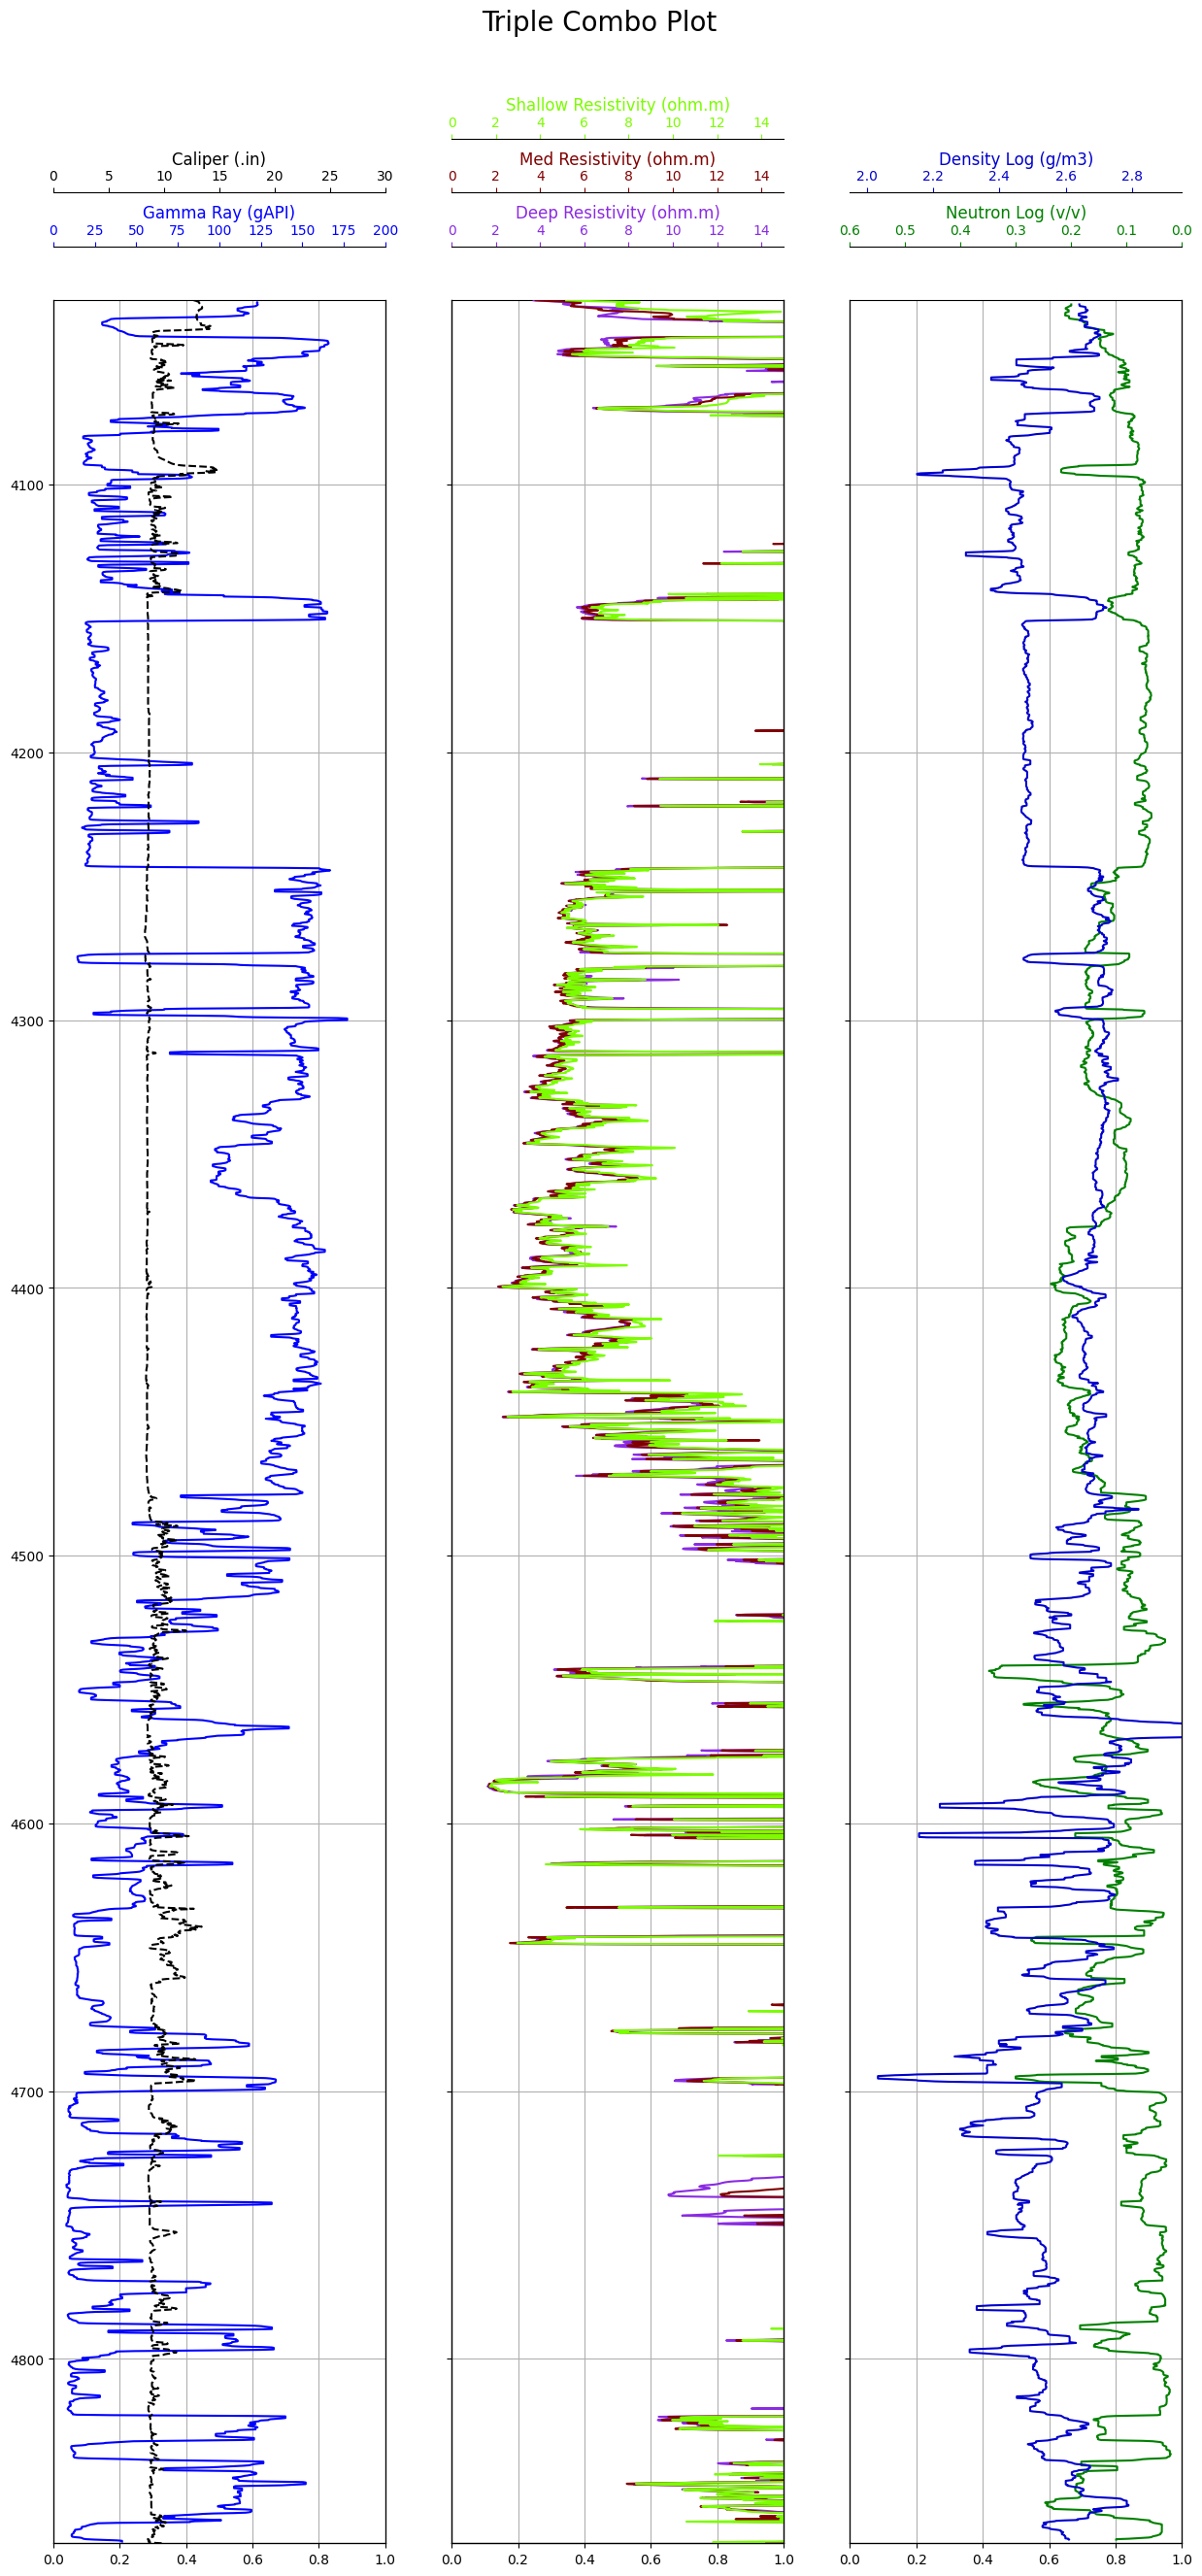

In [14]:
#triple combo plot

fig,ac=plt.subplots(1,3,figsize=(15,30),sharey=True)


fig.suptitle('Triple Combo Plot',fontsize=20)
for ax in ac:
    ax.set_ylim(df2['DEPTH'].min(), df2['DEPTH'].max())

ac2=ac[0].twiny()
ac2.plot(df2['GR_smooth'],df2['DEPTH'],color='blue')
ac2.set_xlim(0,200)
ac2.spines['top'].set_position(('outward',40))
ac2.set_xlabel('Gamma Ray (gAPI)',color='blue',fontsize=12)
ac2.tick_params(axis='x',colors='blue')

ac1=ac[0].twiny()
ac1.plot(df2['CALI'],df2['DEPTH'],color='black',linestyle='--')
ac1.set_xlim(0,30)
ac1.spines['top'].set_position(('outward',80))
ac1.set_xlabel('Caliper (.in)',color='black',fontsize=12)
ac1.tick_params(axis='x',colors='black')
ac[0].grid(True)


ac11=ac[1].twiny()
ac11.plot(df2['RESD'],df2['DEPTH'],color='blueviolet')
ac11.set_xlim(0,15)
ac11.spines['top'].set_position(('outward',40))
ac11.set_xlabel('Deep Resistivity (ohm.m)',color='blueviolet',fontsize=12)
ac11.tick_params(axis='x',colors='blueviolet')

ac12=ac[1].twiny()
ac12.plot(df2['RESM'],df2['DEPTH'],color='maroon')
ac12.set_xlim(0,15)
ac12.spines['top'].set_position(('outward',80))
ac12.set_xlabel('Med Resistivity (ohm.m)',color='maroon',fontsize=12)
ac12.tick_params(axis='x',colors='maroon')

ac13=ac[1].twiny()
ac13.plot(df2['RESS'],df2['DEPTH'],color='lawngreen')
ac13.set_xlim(0,15)
ac13.spines['top'].set_position(('outward',120))
ac13.set_xlabel('Shallow Resistivity (ohm.m)',color='lawngreen',fontsize=12)
ac13.tick_params(axis='x',colors='lawngreen')
ac[1].grid(True)


ac21=ac[2].twiny()
ac21.plot(df2['NPHI_smooth'],df2['DEPTH'],color='green')
ac21.set_xlim(0,0.6)
ac21.invert_xaxis()
ac21.spines['top'].set_position(('outward',40))
ac21.set_xlabel('Neutron Log (v/v)',color='green',fontsize=12)
ac21.tick_params(axis='x',colors='green')

ac22=ac[2].twiny()
ac22.plot(df2['RHOB_smooth'],df2['DEPTH'],color='mediumblue')
ac22.set_xlim(1.95,2.95)
ac22.spines['top'].set_position(('outward',80))
ac22.set_xlabel('Density Log (g/m3)',color='mediumblue',fontsize=12)
ac22.tick_params(axis='x',colors='mediumblue')
ac[2].grid(True)

plt.gca().invert_yaxis()


In [15]:
# Sandstone matrix constants
rho_ma = 2.65   # g/cc
rho_f = 1.0     # g/cc

dt_ma = 55.5    # us/ft
dt_f = 189      # us/ft

In [16]:
df2['PHI_N']= df2['NPHI_smooth'] - 0.04

In [17]:
df2['PHI_D']= (rho_ma-df2['RHOB_smooth'])/(rho_ma-rho_f)

In [18]:
df2['PHI_T']= 0.5*(df2['PHI_N']+ df2['PHI_D'])

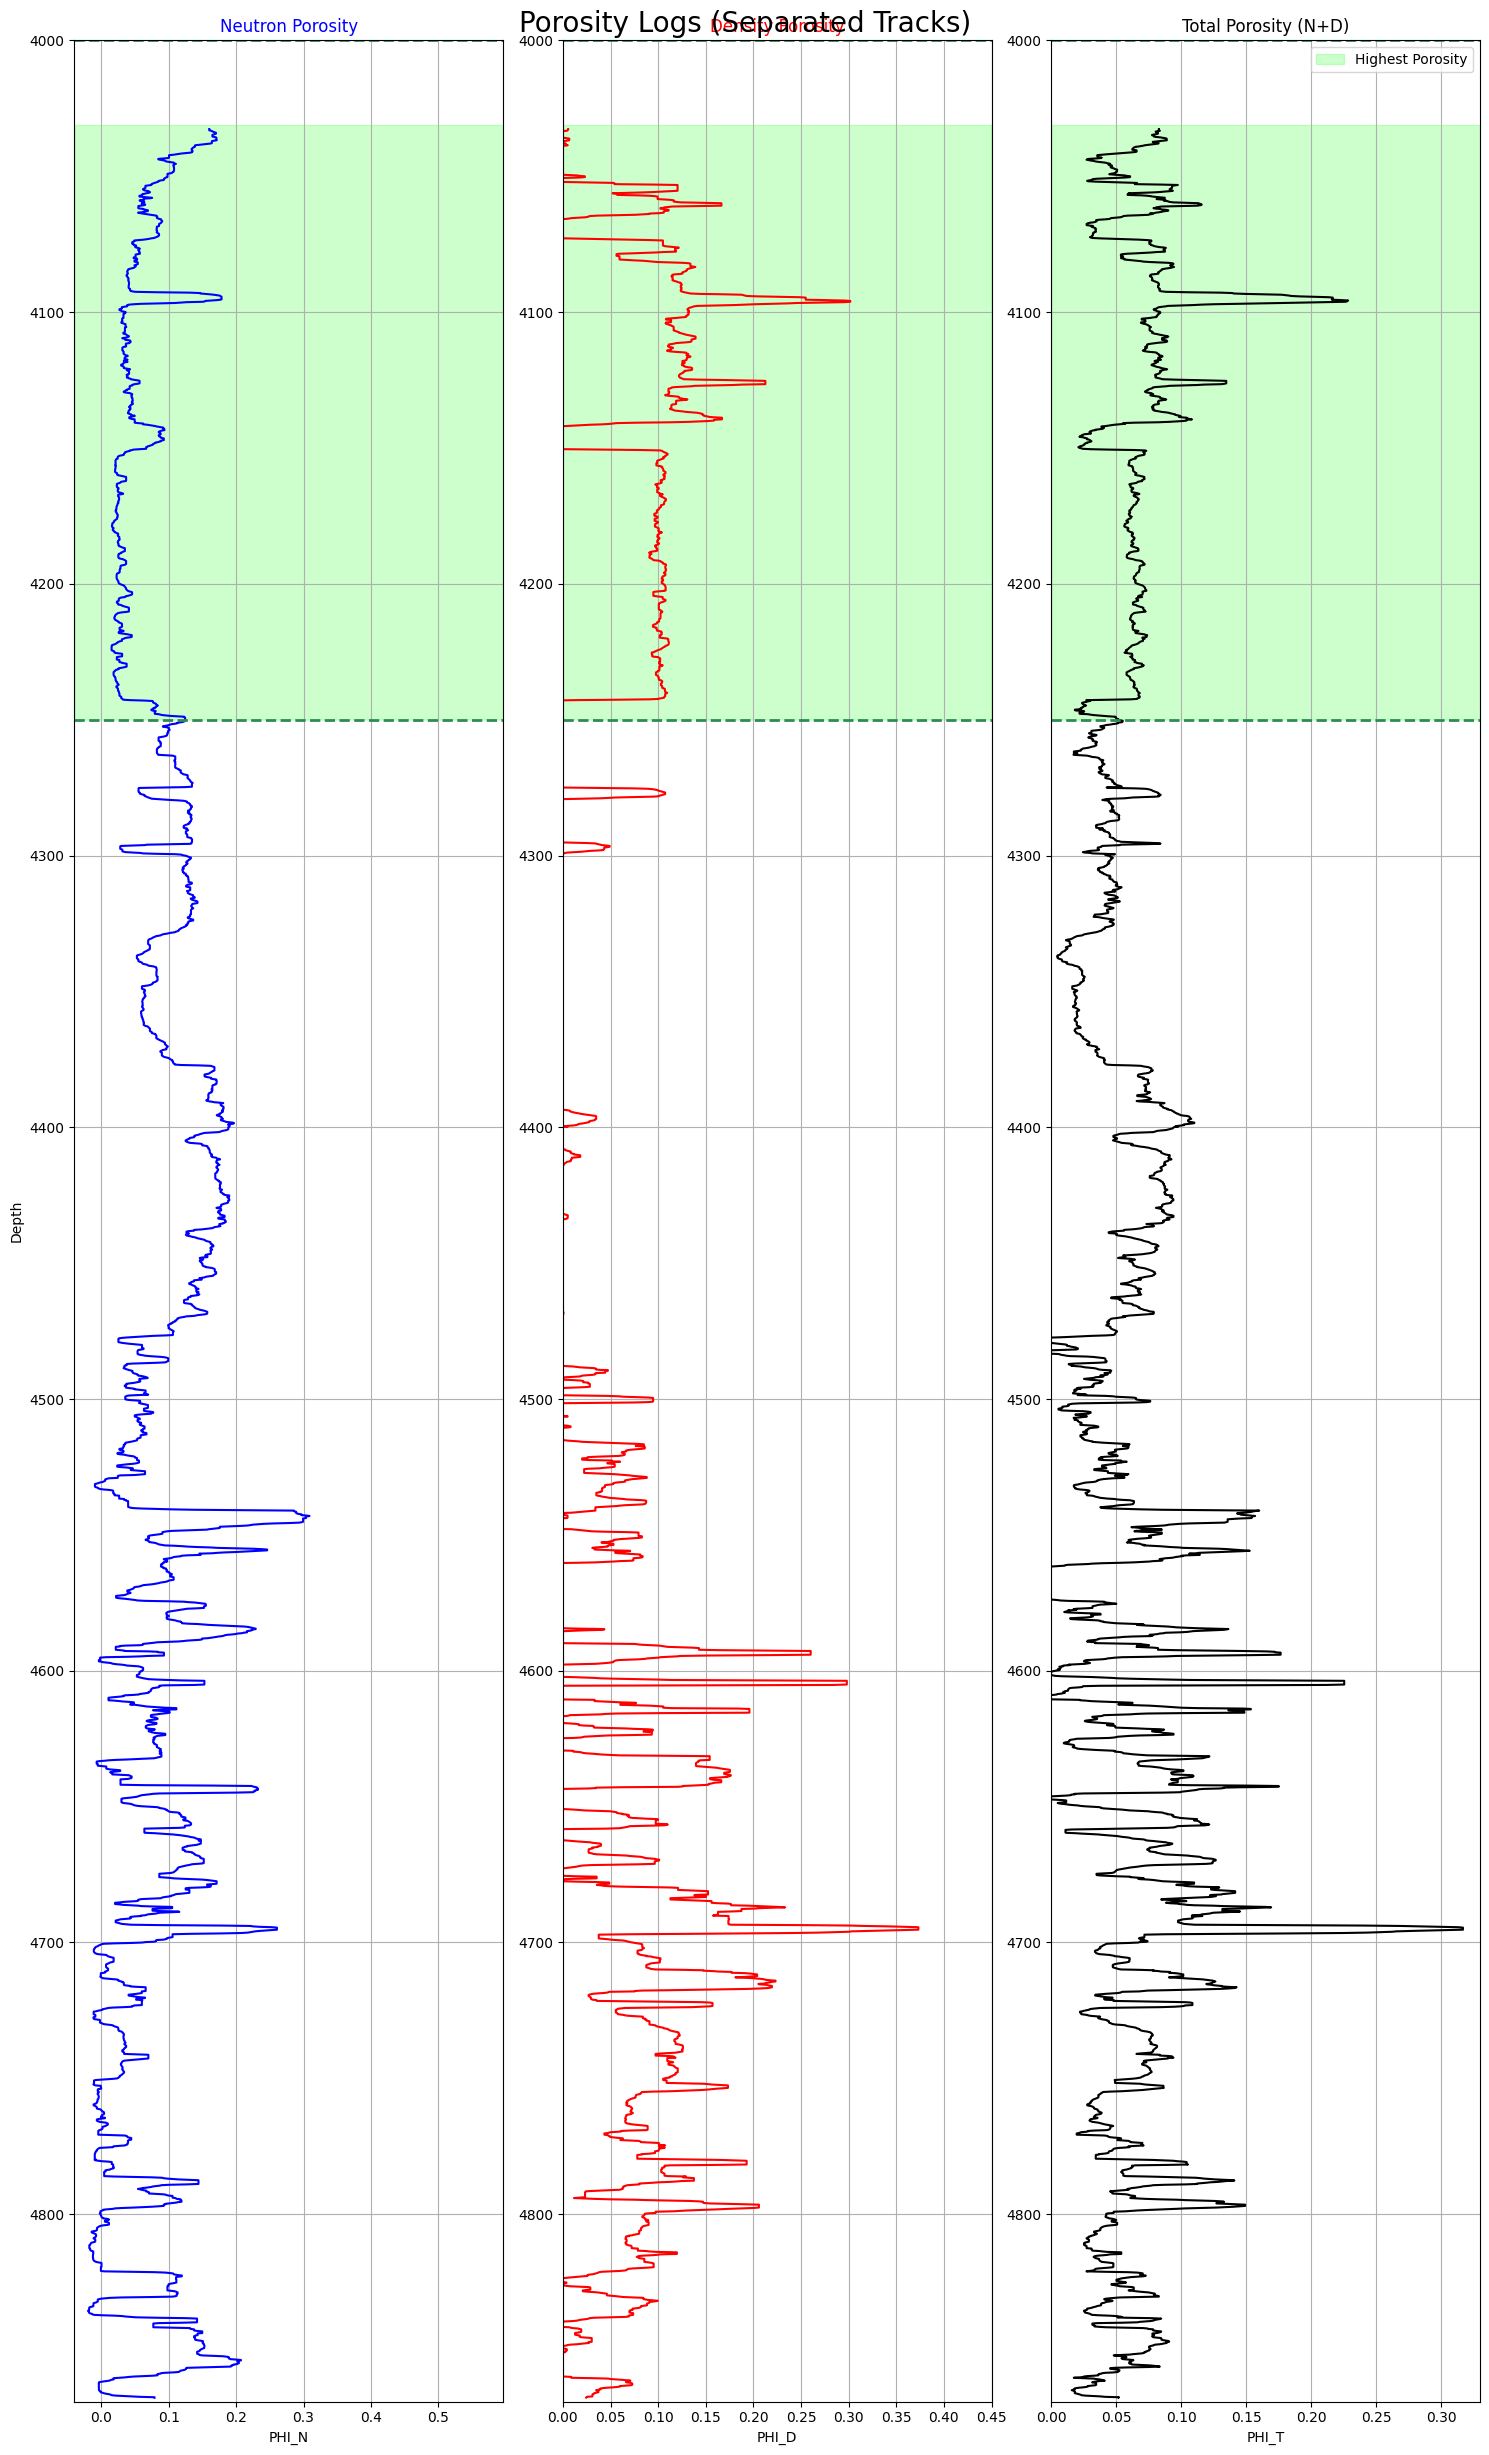

In [19]:
poro_top=4000
poro_bottom=4250

fig, ax = plt.subplots(1, 3, figsize=(15, 25))

for axes in ax:
        axes.set_ylim(4000, bottom_depth)

ax[0].plot(df2['PHI_N'], df2['DEPTH'], color='blue')
ax[0].set_title('Neutron Porosity',color='blue')
ax[0].set_xlim(-0.04,0.596)
ax[0].invert_yaxis()
ax[0].set_xlabel('PHI_N')
ax[0].grid()

# Density
ax[1].plot(df2['PHI_D'], df2['DEPTH'], color='red')
ax[1].set_title('Density Porosity',color='red')
ax[1].set_xlim(0,0.45)
ax[1].invert_yaxis()
ax[1].set_xlabel('PHI_D')
ax[1].grid()

# Total Porosity
ax[2].plot(df2['PHI_T'], df2['DEPTH'], color='black')
ax[2].set_title('Total Porosity (N+D)',color='black')
ax[2].set_xlim(0,0.33)
ax[2].invert_yaxis()
ax[2].set_xlabel('PHI_T')
ax[2].grid()

for a in ax:
    a.axhline(poro_top, color='seagreen', linestyle='--', linewidth=2)
    a.axhline(poro_bottom, color='seagreen', linestyle='--', linewidth=2)

    a.fill_betweenx(
        df2['DEPTH'],
        a.get_xlim()[0],
        a.get_xlim()[1],
        where=(df2['DEPTH'] >=poro_top) & (df2['DEPTH'] <= poro_bottom),
        color="lime",
        label='Highest Porosity',
        alpha=0.2
    )

ax[0].set_ylabel('Depth')

plt.suptitle('Porosity Logs (Separated Tracks)', fontsize=20)
plt.legend()
plt.tight_layout()
plt.show()

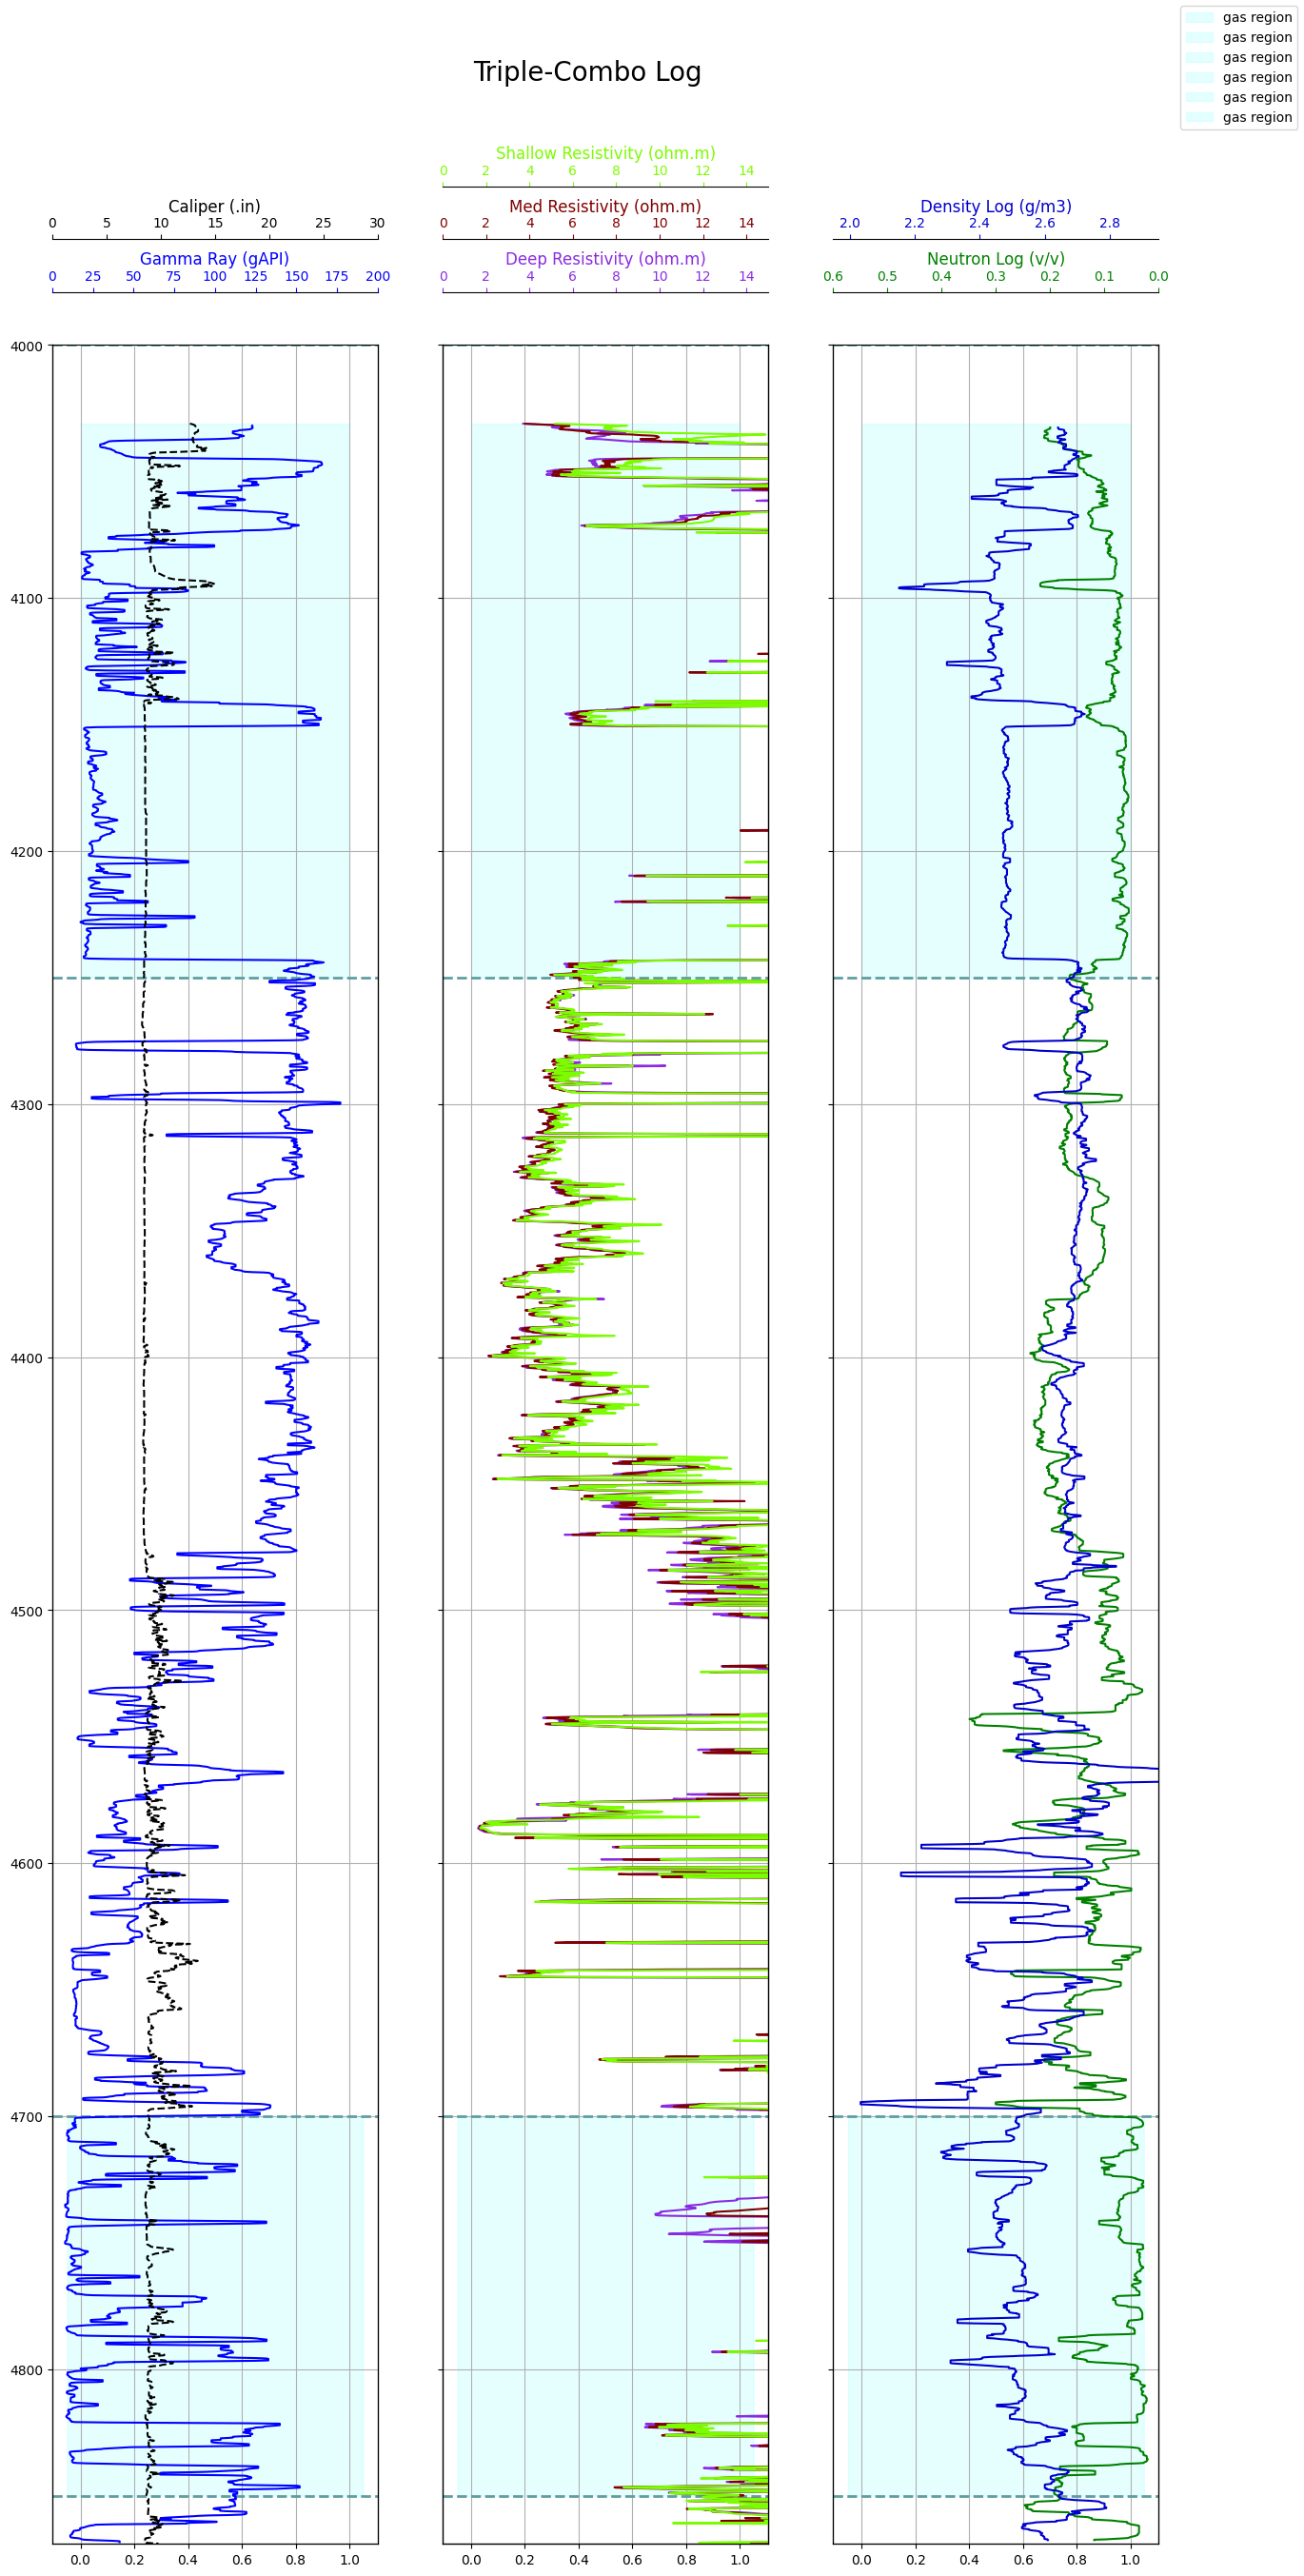

In [22]:
gas_top=4000
gas_bottom=4250

gas1_top=4700
gas1_bottom=4850

fig, ac= plt.subplots(1,3,figsize=(15,30), sharey=True)

fig.suptitle('Triple-Combo Log', fontsize=20)
for axes in ac:
        axes.set_ylim(4000, bottom_depth)

ac2=ac[0].twiny()
ac2.plot(df2['GR_smooth'],df2['DEPTH'],color='blue')
ac2.set_xlim(0,200)
ac2.spines['top'].set_position(('outward',40))
ac2.set_xlabel('Gamma Ray (gAPI)',color='blue',fontsize=12)
ac2.tick_params(axis='x',colors='blue')

ac1=ac[0].twiny()
ac1.plot(df2['CALI'],df2['DEPTH'],color='black',linestyle='--')
ac1.set_xlim(0,30)
ac1.spines['top'].set_position(('outward',80))
ac1.set_xlabel('Caliper (.in)',color='black',fontsize=12)
ac1.tick_params(axis='x',colors='black')
ac[0].grid(True)


ac11=ac[1].twiny()
ac11.plot(df2['RESD'],df2['DEPTH'],color='blueviolet')
ac11.set_xlim(0,15)
ac11.spines['top'].set_position(('outward',40))
ac11.set_xlabel('Deep Resistivity (ohm.m)',color='blueviolet',fontsize=12)
ac11.tick_params(axis='x',colors='blueviolet')

ac12=ac[1].twiny()
ac12.plot(df2['RESM'],df2['DEPTH'],color='maroon')
ac12.set_xlim(0,15)
ac12.spines['top'].set_position(('outward',80))
ac12.set_xlabel('Med Resistivity (ohm.m)',color='maroon',fontsize=12)
ac12.tick_params(axis='x',colors='maroon')

ac13=ac[1].twiny()
ac13.plot(df2['RESS'],df2['DEPTH'],color='lawngreen')
ac13.set_xlim(0,15)
ac13.spines['top'].set_position(('outward',120))
ac13.set_xlabel('Shallow Resistivity (ohm.m)',color='lawngreen',fontsize=12)
ac13.tick_params(axis='x',colors='lawngreen')
ac[1].grid(True)


ac21=ac[2].twiny()
ac21.plot(df2['NPHI_smooth'],df2['DEPTH'],color='green')
ac21.set_xlim(0,0.6)
ac21.invert_xaxis()
ac21.spines['top'].set_position(('outward',40))
ac21.set_xlabel('Neutron Log (v/v)',color='green',fontsize=12)
ac21.tick_params(axis='x',colors='green')

ac22=ac[2].twiny()
ac22.plot(df2['RHOB_smooth'],df2['DEPTH'],color='mediumblue')
ac22.set_xlim(1.95,2.95)
ac22.spines['top'].set_position(('outward',80))
ac22.set_xlabel('Density Log (g/m3)',color='mediumblue',fontsize=12)
ac22.tick_params(axis='x',colors='mediumblue')
ac[2].grid(True)

for axes in ac:
    axes.axhline(gas_top, color='cadetblue', linestyle='--', linewidth=2)
    axes.axhline(gas_bottom, color='cadetblue', linestyle='--', linewidth=2)

    axes.fill_betweenx(
        df2['DEPTH'],
        axes.get_xlim()[0],
        axes.get_xlim()[1],
        where=(df2['DEPTH'] >=gas_top) & (df2['DEPTH'] <= gas_bottom),
        color="aqua",
        label='gas region',
        alpha=0.1
    )

for axes in ac:
    axes.axhline(gas1_top, color='cadetblue', linestyle='--', linewidth=2)
    axes.axhline(gas1_bottom, color='cadetblue', linestyle='--', linewidth=2)

    axes.fill_betweenx(
        df2['DEPTH'],
        axes.get_xlim()[0],
        axes.get_xlim()[1],
        where=(df2['DEPTH'] >=gas1_top) & (df2['DEPTH'] <= gas1_bottom),
        color="aqua",
        label='gas region',
        alpha=0.1
    )

fig.legend()
plt.gca().invert_yaxis()

In [23]:
GRmin= np.percentile(df2['GR'],5)
GRmax= np.percentile(df2['GR'],95)

df2['IGR'] = (df2['GR'] - GRmin)/(GRmax - GRmin)

df2["VSH"] = df2['IGR']

In [24]:
sfs = df2[(df2['VSH'] <= 0.4) & (df2['DEPTH'] >= top_depth) & (df2['DEPTH'] <= bottom_depth)]

In [25]:
sfd = sfs.copy()

sfd = sfd[sfd['PHI_T'] > 0]
sfd['y_val'] = np.log(sfd['PHI_T'] / 0.4)
sf = sfd.dropna(subset=['y_val', 'DEPTH'])

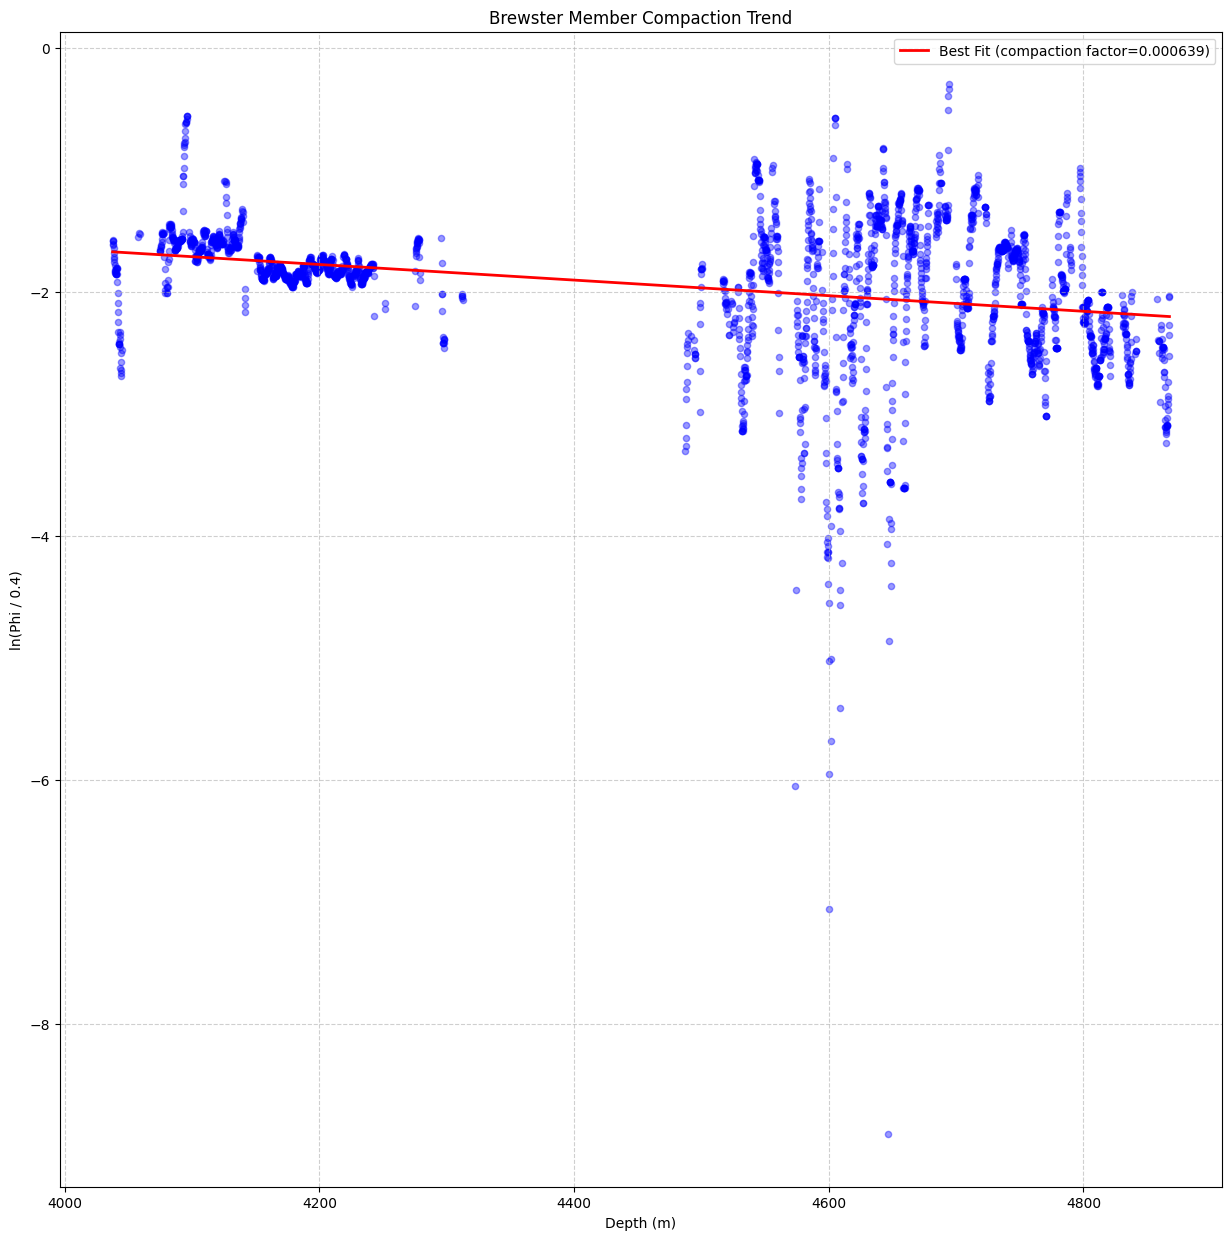

In [26]:
y = np.log(sf['PHI_T'] / 0.4)
x = sf['DEPTH']

plt.figure(figsize=(15,15))
m,b=np.polyfit(x,y,1)
plt.scatter(x,y,alpha=0.4,s=20,color='blue')
plt.plot(x, m*x + b, color='red', linewidth=2, label=f'Best Fit (compaction factor={-m:.6f})')

plt.xlabel('Depth (m)')
plt.ylabel('ln(Phi / 0.4)')
plt.title('Brewster Member Compaction Trend')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [27]:
df2['Vp']= 304800/df2['DTCO']
df2['Vs']= 304800/df2['DTSM_C']

In [31]:


df2['AI'] = df2['Vp'] * df2['RHOB']
df2['SI'] = df2['Vs'] * df2['RHOB']

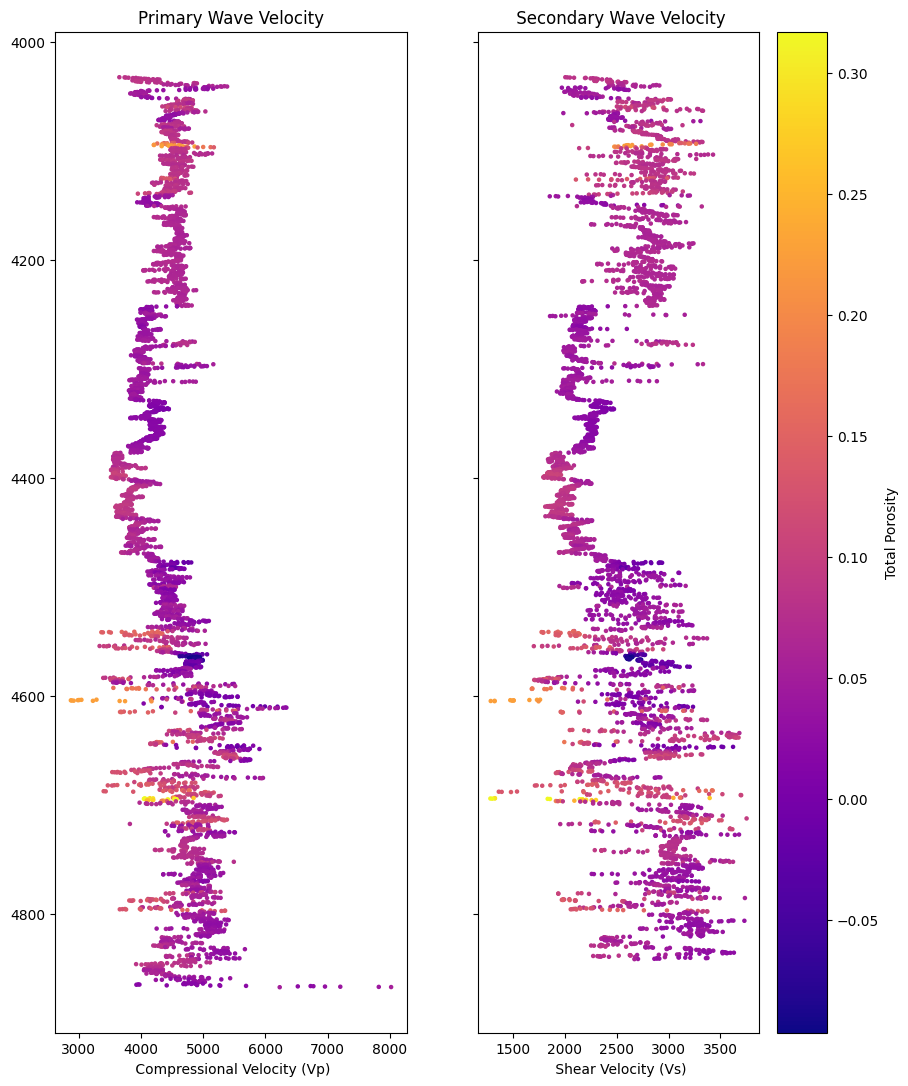

In [34]:
fig,ax = plt.subplots(1,2, figsize=(10,13), sharey= True)

vp = ax[0].scatter(df2['Vp'],df['DEPTH'],c=df2['PHI_T'], cmap='plasma', s=5)
ax[0].set_xlabel(' Compressional Velocity (Vp)')
ax[0].set_title('Primary Wave Velocity')

vs = ax[1].scatter(df2['Vs'],df2['DEPTH'],c=df2['PHI_T'], cmap='plasma' , s=5)
ax[1].set_xlabel(' Shear Velocity (Vs)')
ax[1].set_title(' Secondary Wave Velocity')

ax[0].invert_yaxis()
fig.colorbar(vp,ax=ax[1], label='Total Porosity')
plt.show()

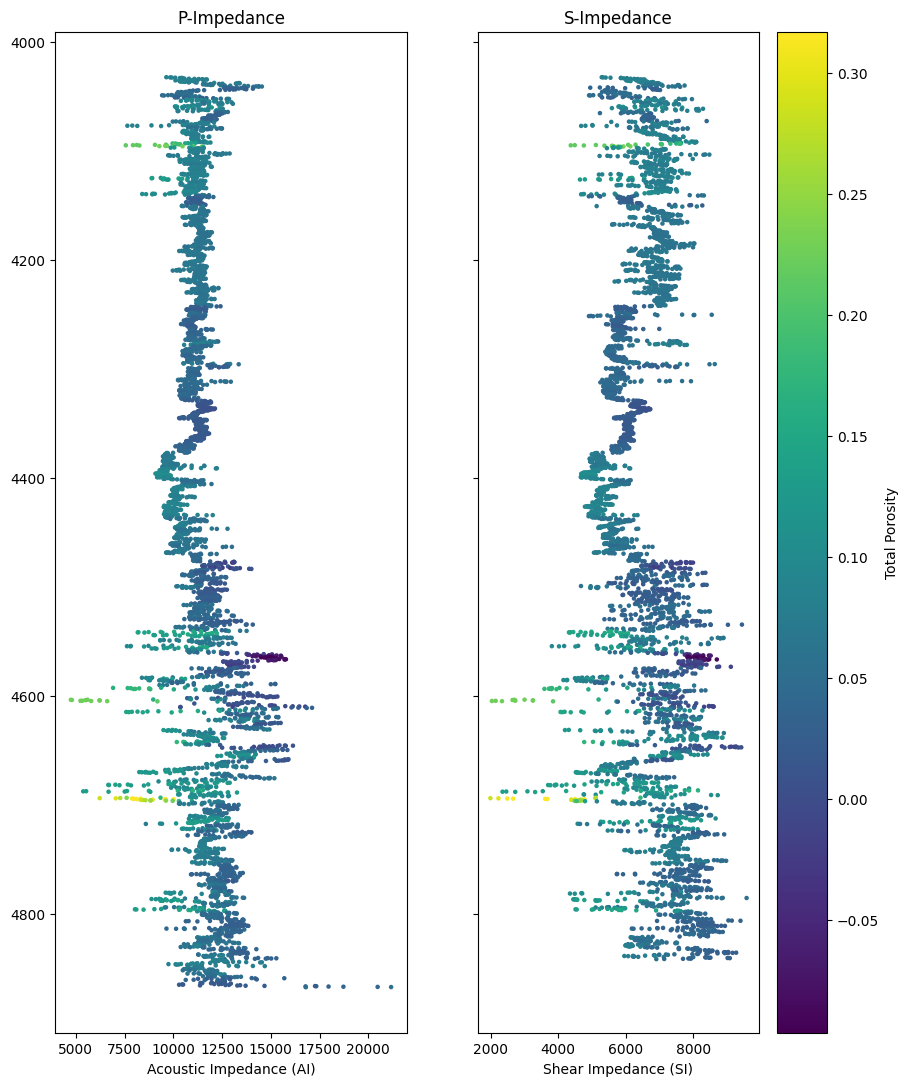

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10, 13), sharey=True)

im1 = ax[0].scatter(df2['AI'], df2['DEPTH'],
                     c=df['PHI_T'], cmap='viridis', s=5)
ax[0].set_xlabel('Acoustic Impedance (AI)')
ax[0].set_title('P-Impedance')

im2 = ax[1].scatter(df2['SI'], df2['DEPTH'],
                     c=df2['PHI_T'], cmap='viridis', s=5)
ax[1].set_xlabel('Shear Impedance (SI)')
ax[1].set_title('S-Impedance')

ax[0].invert_yaxis()
fig.colorbar(im2, ax=ax[1], label='Total Porosity')
plt.show()

In [37]:
df2['RC']=df2['AI'].diff() / (df2['AI'].shift(-1) + df2['AI'])
df2['RC'] = df2['RC'].fillna(0)

In [38]:
def ricker(f, length, dt):
    t = np.arange(-length/2, length/2, dt)
    y = (1.0 - 2.0*(np.pi**2)*(f**2)*(t**2)) * np.exp(-(np.pi**2)*(f**2)*(t**2))
    return t, y

f = 25
dt = 0.001
t, wavelet = ricker(f, 0.128, dt)

In [39]:
df2['synthetic'] = np.convolve(df2['RC'], wavelet, mode='same')

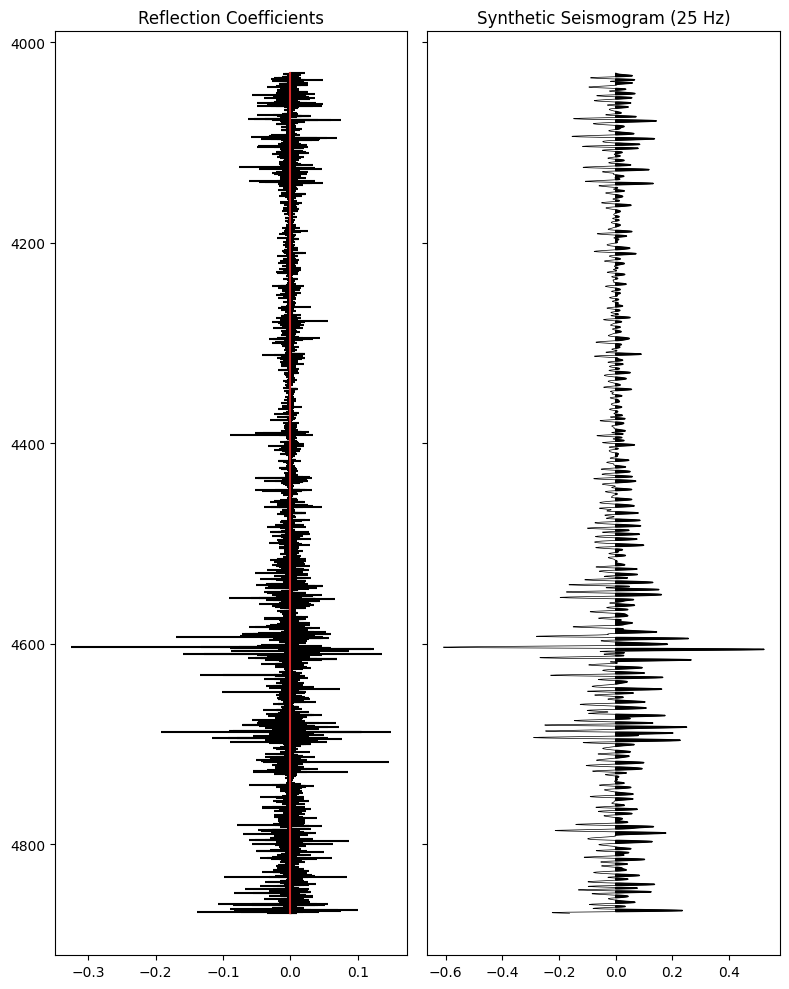

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(8, 10), sharey=True)

ax[0].stem(df2['DEPTH'], df2['RC'], markerfmt=' ', linefmt='black', orientation='horizontal')
ax[0].set_title('Reflection Coefficients')

ax[1].plot(df2['synthetic'], df2['DEPTH'], color='black', lw=0.5)
ax[1].fill_betweenx(df2['DEPTH'], 0, df2['synthetic'], where=(df2['synthetic'] > 0), color='black')
ax[1].set_title('Synthetic Seismogram (25 Hz)')

ax[0].invert_yaxis()
plt.tight_layout()
plt.show()

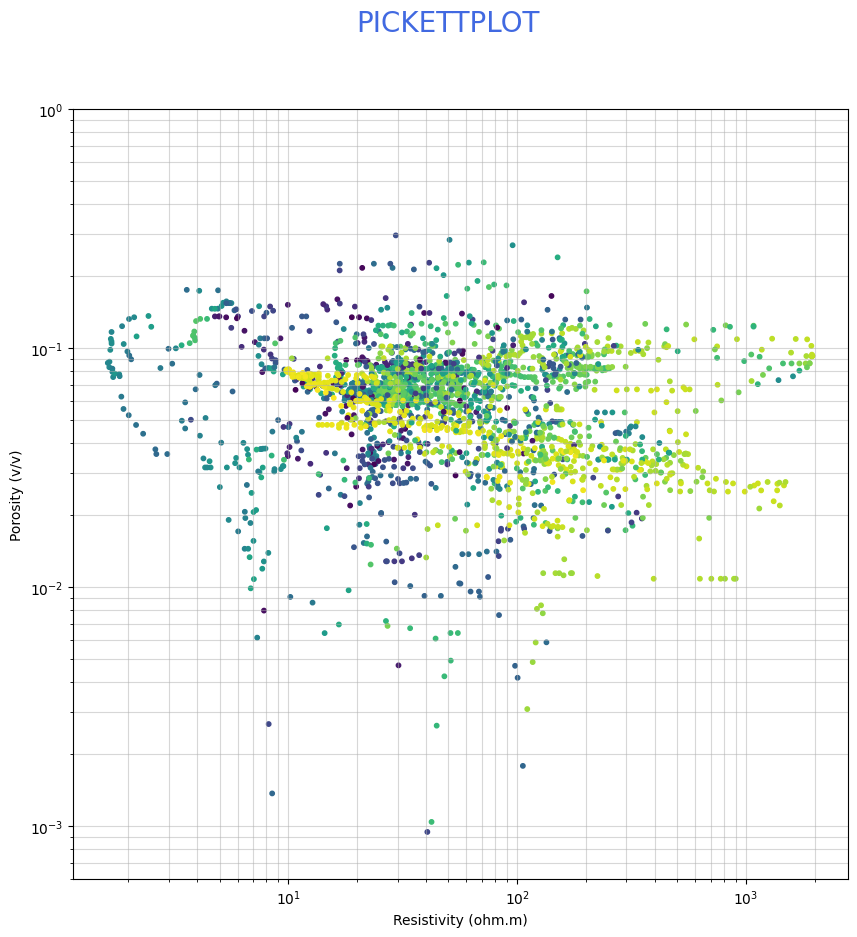

In [45]:
plt.figure(figsize=(10,10))
plt.suptitle('PICKETTPLOT',fontsize=20,color='royalblue')
plt.scatter(sf['RESD'],sf['PHI_T'],c=sf['VSH'],cmap='viridis_r',s=10)

plt.xscale("log")
plt.yscale("log")

plt.xlabel('Resistivity (ohm.m)')
plt.ylabel('Porosity (v/v)')
plt.ylim(0.0006,1)
plt.grid(True, which="both", ls="-", alpha=0.5)